# Load Data

In [1]:
import requests
import pandas as pd

# Approximate location for postcode 2076
lat = -33.72
lon = 151.12

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2010-07-01",
    "end_date": "2013-06-30",
    "hourly": "temperature_2m,shortwave_radiation,precipitation",
    "models": "era5",
    "timezone": "Australia/Sydney",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm",
}

response = requests.get(url, params=params)
response.raise_for_status()

weather = pd.DataFrame(response.json()["hourly"])
weather["time"] = pd.to_datetime(weather["time"])

weather.head()

,time,temperature_2m,shortwave_radiation,precipitation
0,2010-07-01 00:00:00,3.6,0.0,0.0
1,2010-07-01 01:00:00,3.3,0.0,0.0
2,2010-07-01 02:00:00,2.2,0.0,0.0
3,2010-07-01 03:00:00,2.0,0.0,0.0
4,2010-07-01 04:00:00,1.8,0.0,0.0


## Check data quality

In [2]:
import matplotlib.pyplot as plt

# Coverage and time resolution
weather['time'] = pd.to_datetime(weather['time'])
weather = weather.sort_values('time')

print("Coverage:", weather["time"].min(), "to", weather["time"].max())
print("Rows:", len(weather))
print("Duplicate timestamps:", weather["time"].duplicated().sum())

# Time gaps
gaps = weather["time"].diff().dropna()
print("\nTime intervals:")
print(gaps.value_counts().head())

print("\nUnexpected intervals:")
print(gaps[gaps != pd.Timedelta(hours=1)].value_counts())

# Missingness
print("\nMissing values:")
print(weather.isna().sum())
print("\nMissing %:")
print((weather.isna().mean() * 100).round(2))

# Distributions and summary statistics
variables = ["temperature_2m", "shortwave_radiation", "precipitation"]

print("\nSummary statistics:")
print(weather[variables].describe().round(2))

Coverage: 2010-07-01 00:00:00 to 2013-06-30 23:00:00
Rows: 26304
Duplicate timestamps: 0

Time intervals:
time
0 days 01:00:00    26303
Name: count, dtype: int64

Unexpected intervals:
Series([], Name: count, dtype: int64)

Missing values:
time                   0
temperature_2m         0
shortwave_radiation    0
precipitation          0
dtype: int64

Missing %:
time                   0.0
temperature_2m         0.0
shortwave_radiation    0.0
precipitation          0.0
dtype: float64

Summary statistics:
       temperature_2m  shortwave_radiation  precipitation
count        26304.00             26304.00       26304.00
mean            16.20               187.30           0.09
std              5.87               262.58           0.38
min              0.50                 0.00           0.00
25%             12.00                 0.00           0.00
50%             16.30                 7.00           0.00
75%             20.10               347.00           0.00
max             44.10      

- **coverage**: Exactly 3 years, from July 1, 2010 through June 30, 2013
- **Completeness**: 26,304 hourly observations, with no missing values in any of the three variables.
- **Time Consistency**: No gaps or duplicate timestamps, every interval is exactly 1 hour.
- **Temperature**: Mean 16.2°C, range 0.5-44.1°C. The 44.1°C maximum is high but plausible for Sydney.
- **Solar Radiation**: Mean 187 $W/m^2$, with strong day/night signal indicated by the median of only 7 $W/m^2$ and maximum of 1,111 $W/m^2$. Broadly plausible.
- **Precipitation**: Mean 0.09 mm/hour, median 0, maximum 9 mm/hour. The many zeros are expected because rainfall is intermittent.

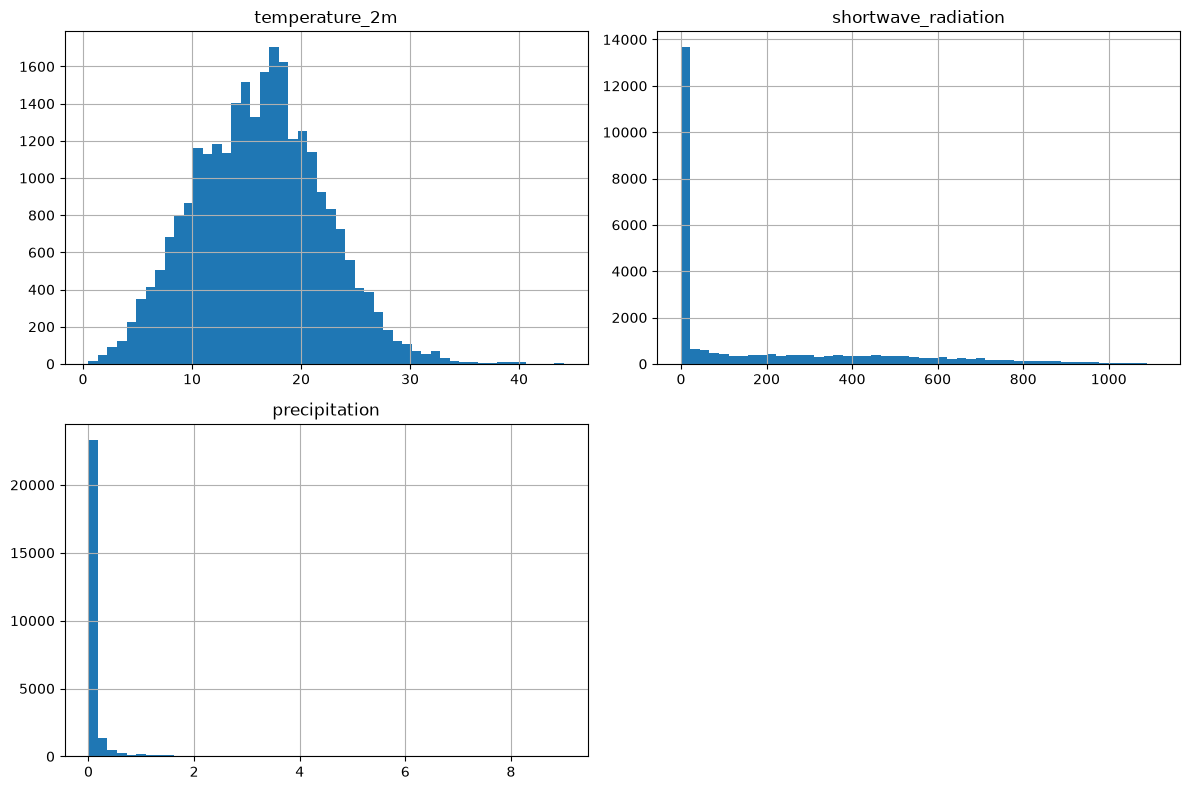

In [3]:
# Histograms
weather[variables].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

- **X-axis**: The measured weather value.
- **Y-axis**: Number of hourly observations falling within each value range.

- **Temperature**: Bell-shaped, centered around 15-20C. The values range from 0-44C, consistent with seasonal temperature variation.
- **Shortwave Radiation**: The large spike near 0 W/m^2 represents nighttime and low-light hours. Values extend to 1,100 W/m^2, with fewer observations at high radiation levels. This strongly right-skewed shape is expected.
- **Precipitation**: The overwhelming majority of hours have no precipitation. This distribution is expected.

## Format datatimes to match Ausgrid Data

In [4]:
# Format datetime to match Ausgrid data
weather["datetime"] = pd.to_datetime(weather["time"]).dt.tz_localize(None)
weather = weather.drop(columns="time")

# Interpolate hourly data to 30-minute resolution
weather = (
    weather.set_index("datetime")
           .resample("30min")
           .interpolate()
           .reset_index())

# Show new table
weather.head()

,datetime,temperature_2m,shortwave_radiation,precipitation
0,2010-07-01 00:00:00,3.60,0.0,0.0
1,2010-07-01 00:30:00,3.45,0.0,0.0
2,2010-07-01 01:00:00,3.30,0.0,0.0
3,2010-07-01 01:30:00,2.75,0.0,0.0
4,2010-07-01 02:00:00,2.20,0.0,0.0


## Save Data

In [6]:
import os

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ausgrid_solar_home_data')
csv_save_filepath = os.path.join(data_dir, 'weather_data_processed.csv')

weather.to_csv(csv_save_filepath, index="False")